## 1. Импорты, настройки и загрузка данных

In [45]:
import json
import warnings
import time
import pickle
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
import optuna
from optuna.samplers import TPESampler

from metric import precision_at_recall

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

ROOT         = Path(".")
FEATURES_DIR = ROOT / "features"
RESULTS_DIR  = ROOT / "results"
PROCESSED_DIR = ROOT / "processed"
RESULTS_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(exist_ok=True)

TARGET       = "target"
RANDOM_STATE = 42
GAP_DAYS     = 0
MIN_TRAIN_DAYS = 9


# Загрузка данных 
if (FEATURES_DIR / "train_features.parquet").exists():
    print("Загрузка из features/train_features.parquet ...")
    train_fe = pd.read_parquet(FEATURES_DIR / "train_features.parquet")
    test_fe  = pd.read_parquet(FEATURES_DIR / "test_features.parquet")
else:
    print("Загрузка из features/train_features.csv ...")
    train_fe = pd.read_csv(FEATURES_DIR / "train_features.csv")
    test_fe  = pd.read_csv(FEATURES_DIR / "test_features.csv")

# Приведение даты
train_fe["window_start_ts"] = pd.to_datetime(train_fe["window_start_ts"])
if "window_start_ts" in test_fe.columns:
    test_fe["window_start_ts"] = pd.to_datetime(test_fe["window_start_ts"])

# Служебные колонки, которые нельзя подавать модели
META_COLS = {"cookie_id", "cookie_created_at", "window_start_ts", "window_end_ts", TARGET}
feature_columns = [c for c in train_fe.columns if c not in META_COLS]
cat_features    = [c for c in feature_columns if train_fe[c].dtype == "object"]
num_features    = [c for c in feature_columns if c not in cat_features]

print(f"train_fe : {train_fe.shape}")
print(f"test_fe  : {test_fe.shape}")
print(f"features : {len(feature_columns)}  (cat={len(cat_features)}, num={len(num_features)})")
print(f"target rate: {train_fe[TARGET].mean():.4f}")

Загрузка из features/train_features.parquet ...
train_fe : (11091, 112)
test_fe  : (4909, 111)
features : 107  (cat=0, num=107)
target rate: 0.0811


## 2. Временная кросс-валидация

В этом блоке строится схема валидации. Разбиение идёт по дням: модель обучается на прошлых днях после этого проверяется на одном следующем дне.


In [46]:
def make_expanding_daily_folds(df, date_col="window_start_ts",
                               gap_days=GAP_DAYS, min_train_days=MIN_TRAIN_DAYS):
    dates = np.array(sorted(df[date_col].dt.normalize().unique()))
    folds = []
    for vp in range(min_train_days + gap_days, len(dates)):
        tr_dates = dates[:vp - gap_days] if gap_days > 0 else dates[:vp]
        va_dates = [dates[vp]]
        if len(tr_dates) < min_train_days:
            continue
        tr = df.index[df[date_col].dt.normalize().isin(tr_dates)].to_numpy()
        va = df.index[df[date_col].dt.normalize().isin(va_dates)].to_numpy()
        if len(tr) and len(va):
            folds.append((tr, va))
    return folds


folds = make_expanding_daily_folds(train_fe)
print(f"\nFolds: {len(folds)}")
for i, (tr, va) in enumerate(folds, 1):
    d_tr_min = train_fe.loc[tr, "window_start_ts"].min().date()
    d_tr_max = train_fe.loc[tr, "window_start_ts"].max().date()
    d_va     = train_fe.loc[va, "window_start_ts"].iloc[0].date()
    print(f"  {i}: train {d_tr_min}..{d_tr_max} ({len(tr)}) | valid {d_va} ({len(va)})")


Folds: 5
  1: train 2026-04-06..2026-04-14 (7599) | valid 2026-04-15 (801)
  2: train 2026-04-06..2026-04-15 (8400) | valid 2026-04-16 (740)
  3: train 2026-04-06..2026-04-16 (9140) | valid 2026-04-17 (713)
  4: train 2026-04-06..2026-04-17 (9853) | valid 2026-04-18 (606)
  5: train 2026-04-06..2026-04-18 (10459) | valid 2026-04-19 (632)


## 3. Метрика и веса объектов

Функция `make_sample_weights` задаёт веса так, чтобы каждый день вносил одинаковый вклад в обучение. Для этого каждому объекту даётся вес, обратный числу куки в его дне, а потом веса нормализуются к среднему значению 1.

In [47]:
def make_sample_weights(df, date_col="window_start_ts"):
    """Равный вклад каждого дня в лосс."""
    sizes = df.groupby(date_col)["cookie_id"].transform("size").astype(float)
    w = (1.0 / sizes).values
    return w / w.mean()

## 4. Препроцессинг для линейных моделей

В этом блоке строится preprocessing для линейных моделей. Для деревьев отдельная обработка не нужна, потому что они умеют работать с пропусками и категориями более естественно.

Для числовых признаков используется заполнение пропусков медианой и масштабирование через `StandardScaler`. Это нужно, чтобы линейная модель корректно работала с признаками разных масштабов.

Для категориальных признаков пропуски заменяются на `"NA"`, а затем применяется One-Hot Encoding. Такой способ безопасен, прост и хорошо подходит при небольшой кардинальности категорий.



In [48]:
def build_linear_preprocessor(num_cols, cat_cols):
    return ColumnTransformer([
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc",  StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="NA")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_cols),
    ])

## 5. Набор моделей для сравнения

В этом блоке задаётся список моделей, которые будут сравниваться на одинаковой кросс-валидации.

Параметры выбраны без сильного тюнинга. На этом этапе задача в том, чтобы честно сравнить модели в одинаковых условиях и выбрать лучший базовый вариант.

In [49]:
# Параметры моделей
MODELS = {
    "LogReg": ("logreg", dict(
        solver="lbfgs", max_iter=2000,
        class_weight="balanced", random_state=RANDOM_STATE,
    )),
    "LightGBM": ("lightgbm", dict(
        objective="binary", metric="average_precision",
        n_estimators=1000, verbose=-1,
    )),
    "XGBoost": ("xgboost", dict(
        objective="binary:logistic", eval_metric="aucpr",
        n_estimators=1000, tree_method="hist",
        early_stopping_rounds=50, verbosity=0,
    )),
    "CatBoost": ("catboost", dict(
        loss_function="Logloss", eval_metric="PRAUC",
        iterations=1000, verbose=0,
        allow_writing_files=False,
    )),
}

## 6. Единый CV runner

Это основной блок, который отвечает за запуск моделей на одинаковых фолдах.

Сначала задаются вспомогательные функции. `_get_features` собирает список признаков и делит их на категориальные и числовые. `_lgbm_data` подготавливает данные для LightGBM, переводя категориальные признаки в тип `category`.

Функция `run_cv` проходит по всем фолдам. На каждом фолде она:
- выделяет train и validation
- выбирает нужные признаки
- считает sample weights
- обучает модель нужного типа
- получает предсказания на train и valid
- считает метрику на train и valid
- сохраняет OOF-предсказания и время обучения


In [50]:
_SKIP_COLS = META_COLS

def _get_features(tr, va, drop=()):
    drop = set(drop)
    feats = [c for c in tr.columns if c not in _SKIP_COLS and c not in drop and c in va.columns]
    cats  = [c for c in feats if tr[c].dtype == "object"]
    nums  = [c for c in feats if c not in cats]
    return feats, cats, nums


def _lgbm_data(tr, va, feats, cats):
    tr_l, va_l = tr[feats].copy(), va[feats].copy()
    for c in cats:
        tr_l[c] = tr_l[c].astype("category")
        va_l[c] = va_l[c].astype("category")
    return tr_l, va_l


def run_cv(model_type, params, train_fe, folds, drop_features=None):
    oof          = np.full(len(train_fe), np.nan)
    fold_scores  = []
    train_scores = []
    fit_times    = []

    _ES_KEYS = {"early_stopping_rounds", "use_best_model"}

    for fold_num, (tr_idx, va_idx) in enumerate(folds, 1):
        tr = train_fe.iloc[tr_idx].reset_index(drop=True)
        va = train_fe.iloc[va_idx].reset_index(drop=True)
        feats, cats, nums = _get_features(tr, va, drop=drop_features or [])
        w = make_sample_weights(tr)

        t0 = time.time()

        if model_type == "catboost":
            p = {k: v for k, v in params.items() if k not in _ES_KEYS}
            model = CatBoostClassifier(**p, random_seed=RANDOM_STATE)
            model.fit(
                Pool(tr[feats], tr[TARGET], cat_features=cats, weight=w),
                eval_set=Pool(va[feats], va[TARGET], cat_features=cats),
                use_best_model=True, early_stopping_rounds=100,
            )
            pred_tr = model.predict_proba(Pool(tr[feats], cat_features=cats))[:, 1]
            pred_va = model.predict_proba(Pool(va[feats], cat_features=cats))[:, 1]

        elif model_type == "lightgbm":
            tr_l, va_l = _lgbm_data(tr, va, feats, cats)
            model = lgb.LGBMClassifier(**params, random_state=RANDOM_STATE)
            model.fit(tr_l, tr[TARGET], sample_weight=w,
                      eval_set=[(va_l, va[TARGET])], categorical_feature=cats,
                      callbacks=[lgb.early_stopping(150, verbose=False)])
            pred_tr = model.predict_proba(tr_l)[:, 1]
            pred_va = model.predict_proba(va_l)[:, 1]

        elif model_type == "xgboost":
            ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
            if cats:
                ohe.fit(tr[cats].astype(str))
                tr_X = np.hstack([tr[nums].fillna(0).values, ohe.transform(tr[cats].astype(str))])
                va_X = np.hstack([va[nums].fillna(0).values, ohe.transform(va[cats].astype(str))])
            else:
                tr_X = tr[nums].fillna(0).values
                va_X = va[nums].fillna(0).values
            p = {k: v for k, v in params.items() if k != "enable_categorical"}
            model = xgb.XGBClassifier(**p, random_state=RANDOM_STATE)
            model.fit(tr_X, tr[TARGET], sample_weight=w,
                      eval_set=[(va_X, va[TARGET])], verbose=False)
            pred_tr = model.predict_proba(tr_X)[:, 1]
            pred_va = model.predict_proba(va_X)[:, 1]

        elif model_type == "logreg":
            model = Pipeline([
                ("prep", build_linear_preprocessor(nums, cats)),
                ("clf",  LogisticRegression(**params)),
            ])
            model.fit(tr[feats], tr[TARGET], clf__sample_weight=w)
            pred_tr = model.predict_proba(tr[feats])[:, 1]
            pred_va = model.predict_proba(va[feats])[:, 1]

        else:
            raise ValueError(model_type)

        fit_times.append(time.time() - t0)
        tr_m = float(precision_at_recall(tr[TARGET].values, pred_tr))
        va_m = float(precision_at_recall(va[TARGET].values, pred_va))
        oof[va_idx] = pred_va
        fold_scores.append(va_m)
        train_scores.append(tr_m)
        print(f"  Fold {fold_num}: train={tr_m:.5f}  valid={va_m:.5f}  "
              f"gap={tr_m-va_m:+.5f}  fit={fit_times[-1]:.1f}s")

    return oof, fold_scores, train_scores, fit_times

## 7. Сравнение базовых моделей

В этом блоке по очереди запускаются все модели из словаря `MODELS`.

In [51]:
results        = {}
oof_predictions = {}
# Прогоняем каждую модель и сохраняем результаты
for name, (mtype, params) in MODELS.items():
    print(f"\n{name}\n")
    oof, scores, tr_scores, times = run_cv(mtype, params, train_fe, folds)
    gaps = np.array(tr_scores) - np.array(scores)
    results[name] = dict(
        mean_ap=np.mean(scores), std_ap=np.std(scores),
        min_ap=np.min(scores),   max_ap=np.max(scores),
        mean_gap=gaps.mean(),    mean_fit_s=np.mean(times),
    )
    oof_predictions[name] = oof

comparison_df = (
    pd.DataFrame(results).T
    .sort_values("mean_ap", ascending=False)
    .round(5)
)
display(comparison_df)
comparison_df.to_csv(RESULTS_DIR / "model_comparison.csv")


LogReg

  Fold 1: train=0.66154  valid=0.79661  gap=-0.13507  fit=0.2s
  Fold 2: train=0.71257  valid=0.60870  gap=+0.10388  fit=0.2s
  Fold 3: train=0.72245  valid=0.68116  gap=+0.04130  fit=0.2s
  Fold 4: train=0.71033  valid=0.51389  gap=+0.19644  fit=0.3s
  Fold 5: train=0.69686  valid=0.72093  gap=-0.02407  fit=0.3s

LightGBM

  Fold 1: train=1.00000  valid=0.90909  gap=+0.09091  fit=0.6s
  Fold 2: train=1.00000  valid=0.79630  gap=+0.20370  fit=0.7s
  Fold 3: train=1.00000  valid=0.85455  gap=+0.14545  fit=2.5s
  Fold 4: train=1.00000  valid=0.74510  gap=+0.25490  fit=0.9s
  Fold 5: train=1.00000  valid=0.91176  gap=+0.08824  fit=0.8s

XGBoost

  Fold 1: train=1.00000  valid=0.90196  gap=+0.09804  fit=0.4s
  Fold 2: train=0.99374  valid=0.71186  gap=+0.28187  fit=0.3s
  Fold 3: train=0.98855  valid=0.74603  gap=+0.24252  fit=0.3s
  Fold 4: train=1.00000  valid=0.82609  gap=+0.17391  fit=1.0s
  Fold 5: train=1.00000  valid=0.89189  gap=+0.10811  fit=0.8s

CatBoost

  Fold 1: trai

,mean_ap,std_ap,min_ap,max_ap,mean_gap,mean_fit_s
LightGBM,0.84336,0.06480,0.74510,0.91176,0.15664,1.08689
CatBoost,0.83236,0.06290,0.76000,0.92727,0.15914,4.76802
XGBoost,0.81557,0.07614,0.71186,0.90196,0.18089,0.56157
LogReg,0.66426,0.09666,0.51389,0.79661,0.03650,0.24562


Заметим, что есть явное переобучение на данных при использовании деревьев. При попытках решения пробовался и исходный датасет и там тоже было переобучение, поэтому можно сказать, что оно связано с малым количеством данных и на данном этапе это можно победить сильной регуляризацией. Я тестировал этот вариант, но модель приходится сильно "душить" и не дает прироста именно в валидирующей метрике. Выбор пал на LGBM, т.к. он быстрее и показал лучшие результаты.

## 8. Permutation importance по фолдам

В этом блоке считается важность признаков через permutation importance на модели LightGBM.

Идея метода: сначала измеряется качество модели на validation, затем значения одного признака перемешиваются, и качество считается заново. Если после перемешивания качество падает, значит признак полезен.

Функция `permutation_importance_manual` делает это для одного validation-набора. Для каждого признака проводится несколько повторов перемешивания, чтобы оценка была стабильнее.

Функция `collect_fold_importances` повторяет этот расчёт на каждом фолде, а затем объединяет результаты. 

In [52]:
def permutation_importance_manual(model, X_val, y_val, cats, n_repeats=5, seed=42):
    def _score(X):
        Xc = X.copy()
        for c in cats:
            if c in Xc.columns:
                Xc[c] = Xc[c].astype("category")
        return precision_at_recall(y_val, model.predict_proba(Xc)[:, 1])

    # Baseline: метрика на исходных (неиспорченных) данных
    baseline = _score(X_val)
    means, stds = [], []

    for col in X_val.columns:
        drops = []
        for _ in range(n_repeats):
            Xp = X_val.copy()
            # Перемешиваем значения признака случайно
            Xp[col] = Xp[col].sample(frac=1, random_state=seed).values
            drops.append(baseline - _score(Xp))
        means.append(np.mean(drops))
        stds.append(np.std(drops))

    return np.array(means), np.array(stds), baseline


def collect_fold_importances(params, train_fe, folds, n_repeats=5):
    """
    Считает permutation importance по всем фолдам и агрегирует результаты.
    """
    all_imps = []

    for fold_num, (tr_idx, va_idx) in enumerate(folds, 1):
        tr = train_fe.iloc[tr_idx].reset_index(drop=True)
        va = train_fe.iloc[va_idx].reset_index(drop=True)
        feats, cats, _ = _get_features(tr, va)
        tr_l, va_l = _lgbm_data(tr, va, feats, cats)
        w = make_sample_weights(tr)
        
        # Обучаем LightGBM на текущем фолде
        model = lgb.LGBMClassifier(**params, random_state=RANDOM_STATE)
        model.fit(tr_l, tr[TARGET], 
                  sample_weight=w,
                  eval_set=[(va_l, va[TARGET])], 
                  categorical_feature=cats,
                  callbacks=[lgb.early_stopping(100, verbose=False),
                              lgb.log_evaluation(-1)])
        
        # Считаем permutation importance на валидационной части фолда
        imp_mean, imp_std, baseline = permutation_importance_manual(
            model, va_l, va[TARGET].values, cats,
            n_repeats=n_repeats, seed=RANDOM_STATE,
        )
        
        # Самый важный признак в этом фолде
        top = feats[int(imp_mean.argmax())]
        print(f"  Fold {fold_num}: baseline={baseline:.5f} | top={top} ({imp_mean.max():.5f})")

        all_imps.append(pd.DataFrame({
            "feature":          feats,
            f"mean_{fold_num}": imp_mean,
            f"std_{fold_num}":  imp_std,
        }))

    # Объединяем все фолды в одну таблицу по колонке feature
    imp_df = all_imps[0][["feature"]].copy()
    for d in all_imps:
        imp_df = imp_df.merge(d, on="feature", how="left")

    # Находим колонки с результатами по фолдам
    mean_cols = [c for c in imp_df.columns if c.startswith("mean_")]
    std_cols  = [c for c in imp_df.columns if c.startswith("std_")]

    imp_df[mean_cols + std_cols] = imp_df[mean_cols + std_cols].fillna(0)
    
    # Среднее падение AP по всем фолдам — основная метрика важности
    imp_df["gain_mean"]        = imp_df[mean_cols].mean(axis=1)
    
    # Разброс важности между фолдами:
    imp_df["gain_std"]         = imp_df[mean_cols].std(axis=1)
    
    # Среднее внутрифолдовое std:
    imp_df["repeat_std_mean"]  = imp_df[std_cols].mean(axis=1)
    
    imp_df["n_folds_positive"] = (imp_df[mean_cols] > 0).sum(axis=1)
    imp_df["n_folds_negative"] = (imp_df[mean_cols] < 0).sum(axis=1)

    # Доля важности признака от суммы всех положительных важностей
    pos_total = imp_df["gain_mean"].clip(lower=0).sum()
    imp_df["gain_pct"] = imp_df["gain_mean"].clip(lower=0) / max(pos_total, 1e-12) * 100

    return (imp_df.sort_values("gain_mean", ascending=False)
                  .reset_index(drop=True)
                  .assign(rank=lambda d: range(1, len(d) + 1)))


print("Collecting permutation importances")
imp_df = collect_fold_importances(MODELS["LightGBM"][1], train_fe, folds, n_repeats=20)
print(f"\nFeatures: {len(imp_df)} | "
      f"positive-all-folds={( imp_df['n_folds_positive']==len(folds)).sum()} | "
      f"negative-3+={(imp_df['n_folds_negative']>=3).sum()}")
imp_df.to_csv(RESULTS_DIR / "feature_importance_permutation.csv", index=False)

  Fold 1: baseline=0.90909 | top=item_pop_mean (0.33409)
  Fold 2: baseline=0.79630 | top=pointer_x_std (0.44336)
  Fold 3: baseline=0.75000 | top=pointer_unique_pts (0.44811)
  Fold 4: baseline=0.74510 | top=pointer_x_std (0.44182)
  Fold 5: baseline=0.91176 | top=pointer_x_std (0.65973)

Features: 107 | positive-all-folds=6 | negative-3+=8


## 9. Визуализация важности признаков

В этом блоке строится график по результатам permutation importance.

Функция `plot_importances` показывает:
- top-N самых важных признаков
- накопленную важность
- стабильность признаков по фолдам

На первом графике признаки дополнительно раскрашиваются по стабильности: видно, какие из них полезны почти всегда, а какие ведут себя нестабильно.

Также внизу печатается короткая сводка: сколько признаков покрывают 80%, 90%, 95% и 99% общей важности, сколько признаков полезны на всех фолдах и сколько выглядят как кандидаты на удаление.

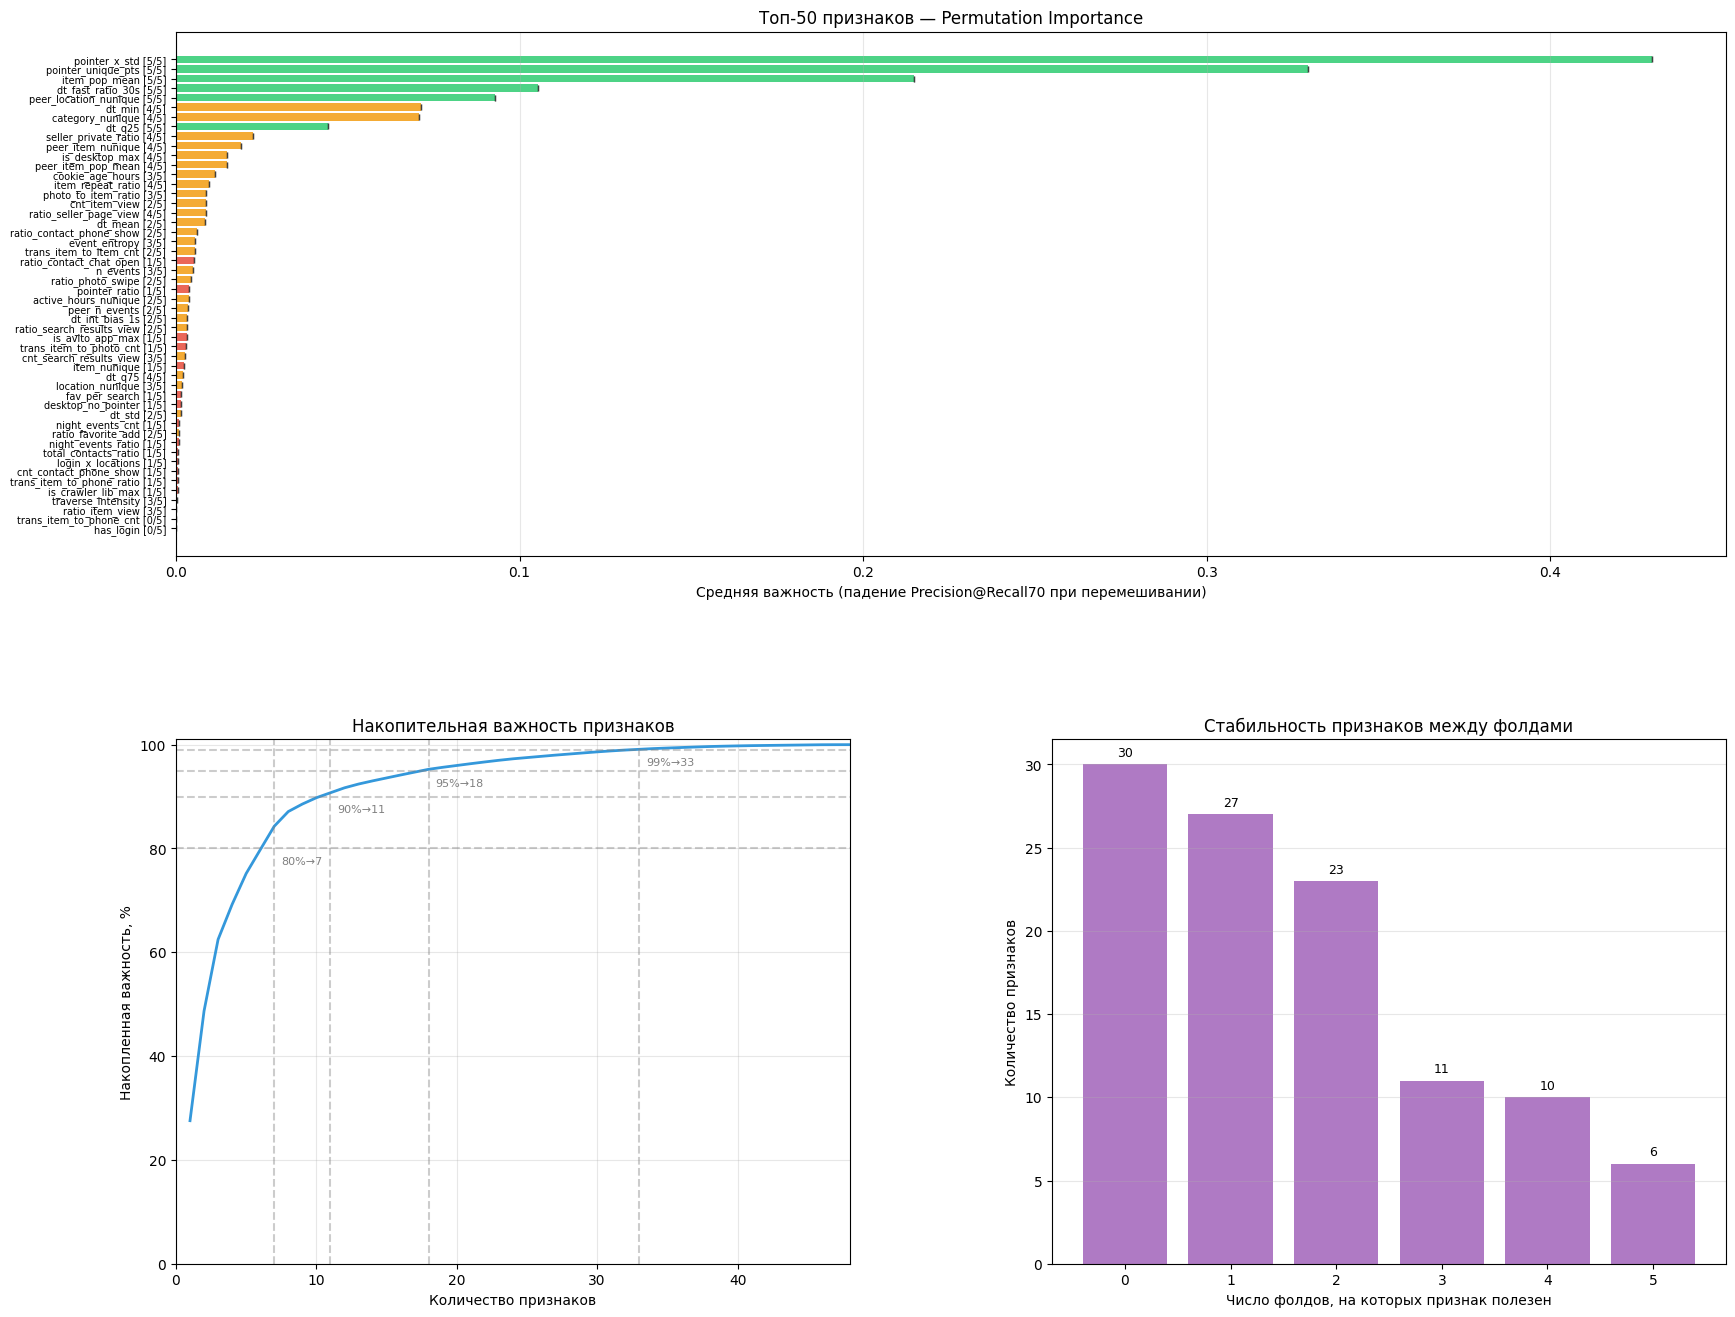


Сводка по PERMUTATION IMPORTANCE
  80% - top 7 features
  90% - top 11 features
  95% - top 18 features
  99% - top 33 features


In [53]:
def plot_importances(imp_df, folds, top_n=50):
    n_folds = len(folds)
    fig = plt.figure(figsize=(20, 16))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

    # top-N признаков
    ax1  = fig.add_subplot(gs[0, :])
    top  = imp_df.head(top_n)
    colors = [
        "#2ecc71" if r["n_folds_positive"] == n_folds
        else "#f39c12" if r["n_folds_positive"] >= n_folds // 2
        else "#e74c3c"
        for _, r in top.iterrows()
    ]
    ax1.barh(range(top_n-1, -1, -1), top["gain_mean"].values, color=colors, alpha=0.85)
    ax1.errorbar(top["gain_mean"].values, range(top_n-1, -1, -1),
                 xerr=top["repeat_std_mean"].values,
                 fmt="none", color="black", alpha=0.5, capsize=2, linewidth=0.8)
    ax1.axvline(0, color="gray", linestyle="--", alpha=0.5)
    ax1.set_yticks(range(top_n-1, -1, -1))
    ax1.set_yticklabels(
        [f"{r['feature']} [{int(r['n_folds_positive'])}/{n_folds}]" for _, r in top.iterrows()],
        fontsize=7)
    ax1.set_xlabel("Средняя важность (падение Precision@Recall70 при перемешивании)")
    ax1.set_title(f"Топ-{top_n} признаков — Permutation Importance")
    ax1.grid(alpha=0.3, axis="x")

    # Накопительная сумма по средней важности
    ax2    = fig.add_subplot(gs[1, 0])
    pos_df = imp_df[imp_df["gain_mean"] > 0]
    cumsum = pos_df["gain_pct"].cumsum().values
    ax2.plot(range(1, len(cumsum)+1), cumsum, color="#3498db", linewidth=2)
    for thr in [80, 90, 95, 99]:
        if cumsum[-1] >= thr:
            n = int(np.searchsorted(cumsum, thr)) + 1
            ax2.axhline(thr, color="gray", linestyle="--", alpha=0.4)
            ax2.axvline(n,   color="gray", linestyle="--", alpha=0.4)
            ax2.text(n+.5, thr-3, f"{thr}%→{n}", fontsize=8, color="gray")
    ax2.set(xlabel="Количество признаков", ylabel="Накопленная важность, %",
            title="Накопительная важность признаков",
            xlim=(0, min(200, len(cumsum))), ylim=(0, 101))
    ax2.grid(alpha=0.3)

    # Количество стабильных на фолдах
    ax3 = fig.add_subplot(gs[1, 1])
    vc  = imp_df["n_folds_positive"].value_counts().sort_index()
    bars = ax3.bar(vc.index, vc.values, color="#9b59b6", alpha=0.8)
    for b, v in zip(bars, vc.values):
        ax3.text(b.get_x()+b.get_width()/2, b.get_height()+.3, str(v),
                 ha="center", va="bottom", fontsize=9)
    ax3.set(xlabel="Число фолдов, на которых признак полезен",
            ylabel="Количество признаков",
            title="Стабильность признаков между фолдами",
            xticks=range(n_folds+1))
    ax3.grid(alpha=0.3, axis="y")

    plt.savefig(RESULTS_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()


    print("\nСводка по PERMUTATION IMPORTANCE")
    for thr in [80, 90, 95, 99]:
        if len(cumsum) and cumsum[-1] >= thr:
            print(f"  {thr}% - top {int(np.searchsorted(cumsum,thr))+1} features")

plot_importances(imp_df, folds, top_n=50)

## Итоги по графику permutation importance

**Топ признаков и их характер**

В самом верху рейтинга находятся признаки, описывающие физическую динамику курсора (указателя) и тайминги действий


**Стабильность признаков**

Тут можно увидеть что самые важные признаки были полезны на всех фолдах, а менее важные не всегда, что говорит о надежности признака при разных данных

**Накопленная важность**

График cumulative importance показывает очень концентрированное распределение:
- 80% важности дают всего **7 признаков**
- 90% важности — **11 признаков**
- 95% важности — **18 признаков**
- 99% важности — **33 признака**

Это значит, что большая часть сигнала сосредоточена в очень небольшом ядре фичей, а остальные признаки в основном дублируют информацию или добавляют шум.

**Стабильность по фолдам**

Правый график показывает, что из всех признаков:
- **30** вообще не дают положительного вклада ни на одном фолде — их можно смело удалять
- **27** полезны только на 1 фолде — скорее всего случайные всплески из за структуры фолда.
- только **6** признака полезны на всех 5 фолдах — это самое надёжные признаки
- ещё **10** полезны на 5 фолдах — тоже стабильные

## 10. Отбор признаков и сравнение подмножеств

После расчёта важности в этом блоке формируются разные наборы признаков и сравниваются между собой.

Функция `select_features` умеет выбирать признаки несколькими способами:
- по накопленной важности, например до 90% или 95%
- по top-N
- по числу фолдов, где признак был полезен
- все признаки с положительной важностью

В конце выбирается лучшее подмножество признаков, которое пойдёт дальше в HPO и финальное обучение.

In [54]:
def select_features(imp_df, strategy="gain_pct", threshold=95):
    """Выбор стратегии отбора фич"""
    neg = set(imp_df[imp_df["gain_mean"] < 0]["feature"])
    pos = imp_df[imp_df["gain_mean"] > 0]

    if strategy == "gain_pct":
        n = int(np.searchsorted(pos["gain_pct"].cumsum().values, threshold)) + 1
        sel = pos.head(n)["feature"].tolist()
    elif strategy == "top_n":
        sel = pos.head(threshold)["feature"].tolist()
    elif strategy == "min_folds":
        sel = imp_df[(imp_df["n_folds_positive"] >= threshold) &
                     (imp_df["gain_mean"] > 0)]["feature"].tolist()
    elif strategy == "nonzero":
        sel = pos["feature"].tolist()
    else:
        raise ValueError(strategy)

    print(f"  {strategy}={threshold}: {len(sel)} features  ({len(neg)} negative dropped)")
    return sel


n_folds = len(folds)
subsets = {
    "all_features":     [c for c in train_fe.columns if c not in _SKIP_COLS],
    "gain_pct_95":      select_features(imp_df, "gain_pct", 95),
    "gain_pct_90":      select_features(imp_df, "gain_pct", 90),
    "top100":           select_features(imp_df, "top_n", 100),
    "stable_all_folds": select_features(imp_df, "min_folds", n_folds),
    "nonzero":          select_features(imp_df, "nonzero"),
}


def compare_subsets(subsets, params, train_fe, folds):
    """Сравнение разных множеств признаков"""
    print("\nСводка")
    results = {}

    for name, features in subsets.items():
        fold_scores = []
        for fold_num, (tr_idx, va_idx) in enumerate(folds, 1):
            tr = train_fe.iloc[tr_idx].reset_index(drop=True)
            va = train_fe.iloc[va_idx].reset_index(drop=True)
            
            use = [c for c in features if c in tr.columns and c in va.columns]
            cats = [c for c in use if tr[c].dtype == "object"]
            
            tr_l, va_l = _lgbm_data(tr, va, use, cats)
            w = make_sample_weights(tr)
            
            model = lgb.LGBMClassifier(**params, random_state=RANDOM_STATE)
            model.fit(tr_l, tr[TARGET], sample_weight=w,
                      eval_set=[(va_l, va[TARGET])], categorical_feature=cats,
                      callbacks=[lgb.early_stopping(50, verbose=False),
                                  lgb.log_evaluation(-1)])
            preds_va = model.predict_proba(va_l)[:, 1]
            fold_scores.append(precision_at_recall(va[TARGET].values, preds_va))

        m, s = float(np.mean(fold_scores)), float(np.std(fold_scores))
        results[name] = {"mean": m, "std": s, "folds": fold_scores}
        print(f"  {name:22s}: {m:.5f} ± {s:.5f}  "
              f"[{' | '.join(f'{x:.4f}' for x in fold_scores)}]  n={len(features)}")
    return results


subset_results = compare_subsets(subsets, MODELS["LightGBM"][1], train_fe, folds)
best_subset_name = max(subset_results, key=lambda k: subset_results[k]["mean"])
best_subset_features = subsets[best_subset_name]
print(f"\nBest: {best_subset_name}  "
      f"Precision@R70={subset_results[best_subset_name]['mean']:.5f}  "
      f"n={len(best_subset_features)}")

  gain_pct=95: 18 features  (40 negative dropped)
  gain_pct=90: 11 features  (40 negative dropped)
  top_n=100: 48 features  (40 negative dropped)
  min_folds=5: 6 features  (40 negative dropped)
  nonzero=95: 48 features  (40 negative dropped)

Сводка
  all_features          : 0.82655 ± 0.07038  [0.9091 | 0.7963 | 0.7705 | 0.7451 | 0.9118]  n=107
  gain_pct_95           : 0.79289 ± 0.05137  [0.8679 | 0.7797 | 0.7581 | 0.7255 | 0.8333]  n=18
  gain_pct_90           : 0.78494 ± 0.08198  [0.8571 | 0.7963 | 0.8393 | 0.6271 | 0.8049]  n=11
  top100                : 0.80273 ± 0.07797  [0.8868 | 0.8571 | 0.6620 | 0.7872 | 0.8205]  n=48
  stable_all_folds      : 0.71858 ± 0.08147  [0.8364 | 0.7414 | 0.6714 | 0.5938 | 0.7500]  n=6
  nonzero               : 0.80273 ± 0.07797  [0.8868 | 0.8571 | 0.6620 | 0.7872 | 0.8205]  n=48

Best: all_features  Precision@R70=0.82655  n=107


Baseline на всех 744 фичах даёт лучший результат **0.82655**. Конечно это не подтвердило, что слабые фичи можно легко отбросить и они вносили какой-то вклад, но заметим, что gap 0.07038, что от запуска к запуска может сильно варьироваться, поэтому финальное решение для стабильности будет браться ансамблем по сидам

## 11. HPO для LightGBM через Optuna

В этом блоке запускается подбор гиперпараметров для LightGBM на лучшем наборе признаков.

Подбираются параметры, которые влияют на сложность модели, регуляризацию, sampling и структуру деревьев. Поиск идёт не на одном split, а на всей временной кросс-валидации, поэтому результат получается более надёжным.

In [55]:
def lgbm_objective(trial, train_fe, folds, features):
    
    # Задаем параметры подбора
    params = dict(
        objective         = "binary",
        metric            = "average_precision",
        boosting_type     = "gbdt",
        n_estimators      = trial.suggest_int("n_estimators", 300, 3000, step=100),
        learning_rate     = trial.suggest_float("learning_rate", 1e-2, 0.2, log=True),
        num_leaves        = trial.suggest_int("num_leaves", 8, 512),
        max_depth         = trial.suggest_int("max_depth", 3, 7),
        min_child_samples = trial.suggest_int("min_child_samples", 5, 200),
        min_child_weight  = trial.suggest_float("min_child_weight", 1e-4, 10.0, log=True),
        subsample         = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha         = trial.suggest_float("reg_alpha",  1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        min_split_gain    = trial.suggest_float("min_split_gain", 0.0, 1.0),
        max_bin           = trial.suggest_int("max_bin", 64, 512, step=32),
        verbose           = -1,
    )

    fold_scores = []
    for fold_num, (tr_idx, va_idx) in enumerate(folds):
        tr = train_fe.iloc[tr_idx].reset_index(drop=True)
        va = train_fe.iloc[va_idx].reset_index(drop=True)
        
        use  = [c for c in features if c in tr.columns and c in va.columns]
        cats = [c for c in use if tr[c].dtype == "object"]
        
        tr_l, va_l = _lgbm_data(tr, va, use, cats)
        w = make_sample_weights(tr)

        model = lgb.LGBMClassifier(**params, random_state=RANDOM_STATE)
        model.fit(tr_l, tr[TARGET], sample_weight=w,
                  categorical_feature=cats,
                  callbacks=[lgb.log_evaluation(-1)])

        preds_va = model.predict_proba(va_l)[:, 1]
        fold_scores.append(precision_at_recall(va[TARGET].values, preds_va))
        trial.report(np.mean(fold_scores), step=fold_num)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return float(np.mean(fold_scores))


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE, n_startup_trials=10, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
)
study.optimize(
    lambda t: lgbm_objective(t, train_fe, folds, best_subset_features),
    n_trials=100, show_progress_bar=True, gc_after_trial=True,
)
print(f"\nHPO best: {study.best_value:.6f}")
for k, v in study.best_params.items():
    print(f"  {k:30s} = {v}")

  0%|          | 0/100 [00:00<?, ?it/s]


HPO best: 0.858822
  n_estimators                   = 1500
  learning_rate                  = 0.011784419113113674
  num_leaves                     = 238
  max_depth                      = 7
  min_child_samples              = 167
  min_child_weight               = 0.020999195382417207
  subsample                      = 0.577994907983686
  colsample_bytree               = 0.8229514987907902
  reg_alpha                      = 0.22038608084884018
  reg_lambda                     = 7.361213414716569e-05
  min_split_gain                 = 0.7707872750994699
  max_bin                        = 128


После Optuna тоже заметен прирост на 0.3. Неплохой результат.

In [58]:
def build_final_params(best_params):
    p = best_params
    return dict(
        objective         = "binary",
        metric            = "average_precision",
        boosting_type     = "gbdt",
        n_estimators      = p.get("n_estimators", 500),
        learning_rate     = p.get("learning_rate", 0.05),
        num_leaves        = p.get("num_leaves", 64),
        max_depth         = p.get("max_depth", 6),
        min_child_samples = p.get("min_child_samples", 20),
        min_child_weight  = p.get("min_child_weight", 1e-3),
        subsample         = p.get("subsample", 0.8),
        colsample_bytree  = p.get("colsample_bytree", 0.8),
        reg_alpha         = p.get("reg_alpha", 1e-5),
        reg_lambda        = p.get("reg_lambda", 1e-5),
        min_split_gain    = p.get("min_split_gain", 0.0),
        max_bin           = p.get("max_bin", 255),
        verbose           = -1,
    )

FINAL_LGBM_PARAMS = build_final_params(study.best_params)

## 12. Финальное обучение и submission

В этом блоке обучается финальная модель на полном train и строятся предсказания для test.


Собирается таблица `submission` с двумя колонками: `cookie_id` и `score`.

In [60]:
def final_predict(params, features, train_fe, test_fe, seeds=(42,52)):
    """TОбучение на всем датасете и ансамблирование"""
    use  = [c for c in features if c in train_fe.columns and c in test_fe.columns]
    cats = [c for c in use if train_fe[c].dtype == "object"]
    w    = make_sample_weights(train_fe)

    tr_l = train_fe[use].copy()
    te_l = test_fe[use].copy()
    for c in cats:
        tr_l[c] = tr_l[c].astype("category")
        te_l[c] = te_l[c].astype("category")

    preds = []
    for seed in seeds:
        model = lgb.LGBMClassifier(**params, random_state=seed)
        model.fit(tr_l, train_fe[TARGET], sample_weight=w,
                  categorical_feature=cats,
                  callbacks=[lgb.log_evaluation(-1)])
        preds.append(model.predict_proba(te_l)[:, 1])

    return np.mean(preds, axis=0)


print("Final training")
test_pred = final_predict(FINAL_LGBM_PARAMS, best_subset_features, train_fe, test_fe)

submission = pd.DataFrame({
    "cookie_id": test_fe["cookie_id"].astype(str),
    "score":     test_pred.astype(float),
})
assert list(submission.columns) == ["cookie_id", "score"]
assert submission["cookie_id"].is_unique
assert submission["score"].between(0, 1).all()

submission.to_csv(ROOT / "submission.csv", index=False)
print(f"submission.csv  {submission.shape}")
print(submission.head())

Final training
submission.csv  (4909, 2)
             cookie_id     score
0  ck_315fb710a0e371e7  0.002872
1  ck_a76ee3b3e3e522fd  0.064780
2  ck_94c9a4d382689e82  0.022954
3  ck_8eaf9509ad9462a0  0.001212
4  ck_9a88a5a989cb5bc6  0.005825


## 14. Сохранение всего

В последнем блоке сохраняются все результаты работы ноутбука.

Сохраняются:
- OOF-предсказания всех моделей
- информация о выбранном наборе признаков
- результаты HPO и все trial
- pickle-файл со study
- финальные параметры LightGBM
- итоговая сводка по эксперименту

После этого в папках `results` и `processed` остаются все основные параметры, чтобы можно было быстро вернуться к результатам, не пересчитывая всё заново.

In [61]:
# OOF
oof_df = train_fe[["cookie_id", "window_start_ts", TARGET]].copy()
for name, oof in oof_predictions.items():
    oof_df[f"oof_{name}"] = oof
oof_df.to_csv(RESULTS_DIR / "oof_predictions.csv", index=False)

# Feature selection meta
with open(PROCESSED_DIR / "feature_selection.json", "w") as f:
    json.dump({
        "best_subset_name":     best_subset_name,
        "best_subset_features": best_subset_features,
        "n_features":           len(best_subset_features),
        "subsets_compared": {
            k: {"mean": v["mean"], "std": v["std"],
                "n": len(subsets[k]), "folds": v["folds"]}
            for k, v in subset_results.items()
        },
    }, f, indent=2)

# HPO
with open(RESULTS_DIR / "hpo_meta.json", "w") as f:
    json.dump({
        "best_value":   float(study.best_value),
        "best_trial":   study.best_trial.number,
        "best_params":  study.best_params,
        "n_trials":     len(study.trials),
        "completed":    sum(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials),
        "pruned":       sum(t.state == optuna.trial.TrialState.PRUNED   for t in study.trials),
        "n_features":   len(best_subset_features),
    }, f, indent=2)
study.trials_dataframe().to_csv(RESULTS_DIR / "hpo_trials.csv", index=False)
with open(RESULTS_DIR / "hpo_study.pkl", "wb") as f:
    pickle.dump(study, f)

# Final params
with open(RESULTS_DIR / "final_lgbm_params.json", "w") as f:
    json.dump(FINAL_LGBM_PARAMS, f, indent=2)

# Summary
summary = {
    "hpo_best_ap":        float(study.best_value),
    "best_subset":        best_subset_name,
    "n_features_final":   len(best_subset_features),
    "best_baseline_model": comparison_df.index[0],
    "best_baseline_ap":   float(comparison_df.iloc[0]["mean_ap"]),
}
with open(RESULTS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)



`Подводя итоги`: был произведен EDA, обработка пропусков, дупликатов и Feature engineering (+100 признаков). Обучена модель LGBM, произведен Feature selection с помощью permutation importance, который не дал прироста (Возможно если бы сделал больше признаков, он бы сработал лучше, но по сути значит не была так такового шума). Был произведен подбор гиперпараметров и в итоге на валидации `P@R >= 70 = 0.85`

Модель использует исходные табличные признаки, признаки времени, дополнительные производные (mean, min, max, std, "/") из исходных признаков и других фич, агрегаты из `events.csv`. События фильтруются условием заданным задачей до любой агрегации.

Основная модель — LGBM. Самый первый Baseline, предоставленный разработчиками на val дал 0.1, был произведен FE, что дало примерно 0.7-0.74 с optuna. Результат не устроил поэтому был произведен доп. FE, который дал 0.85. Feature selection не дал прироста. Финальным ответом это ансамбль с разными сидами, чтобы уменьшить variance.
